In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

from tqdm import tqdm
from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
type EnergyRange = tuple[float, float]

def extract_flx(filepath: str | Path) -> tuple[NDArray, NDArray]:
    """Extracts energy bins and flux arrays from FITS file."""
    flx_rec: FITS_rec = fits.getdata(Path(filepath), ext=1, header=False)
    return flx_rec['EBINS'], flx_rec['FLUX'][:-1]

def get_eband_flx_fract(ebins: NDArray, flux: NDArray, eband: EnergyRange) -> float:
    """Computes the source flux fraction in given energy band."""
    low, high = eband
    band: NDArray = np.where((ebins >= low) & (ebins <= high))[0][:-1]
    return flux[band].sum() / flux.sum()

MFLX_FILE: str = 'RXTE-ASM_BeppoSAX-WFC_catalog_2-50keV_MeanAvgFluxCrablike.fits'
ENERGYBINS, MEANFLX_ARR = extract_flx(
    f'/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings/{MFLX_FILE}'
)

def get_flx_fracts(energy_bands: tuple[EnergyRange, ...]) -> tuple[float, ...]:
    """Computes the source flux fractions in selected energy bands."""
    fractions: tuple[float, ...] = tuple(
        get_eband_flx_fract(ENERGYBINS, MEANFLX_ARR, eband) for eband in energy_bands
    )
    return fractions

In [3]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [4]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [5]:
from bloodmoon.images import fshift
from bloodmoon.mask import decode
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import apply_detector_resolution, apply_vignetting

type CoordSky = tuple[float, float]


def _project_mask_pattern(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    """Projects the camera mask pattern on the detector plane."""
    pxdimy, pxdimx = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    fr, fc = (
        (-1.0) * shift_y / pxdimy,
        (-1.0) * shift_x / pxdimx,
    )
    mask_shifted = fshift(camera.mask.astype(float), fr, fc)
    return mask_shifted

def _process_mask_pattern(
    camera: CodedMaskCamera,
    mask_pattern: NDArray,
    shift_x: float,
    shift_y: float,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Applies instrumental effects to the mask pattern projection."""
    mp_vignetted: NDArray = (
        apply_vignetting(camera, mask_pattern, shift_x, shift_y)
        if vignetting else mask_pattern
    )
    mp_psfy: NDArray = (
        apply_detector_resolution(camera, mp_vignetted)
        if psfy else mp_vignetted
    )
    return mp_psfy

def _extract_detector(
    camera: CodedMaskCamera,
    mask_projection: NDArray,
) -> NDArray:
    """
    Extracts the detector image from the mask pattern projection on the detector plane.
    """
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = mask_projection[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    detector /= np.sum(detector)
    return detector


def model_source_sg(
    camera: CodedMaskCamera,
    coords: dict[EnergyRange, CoordSky],
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """
    Generates a source detector image as superimposition
    of shadowgrams in given energy bands.
    """
    flx_fracts: tuple[float, ...] = get_flx_fracts(tuple(coords.keys()))
    detector: NDArray = np.zeros(camera.shape_detector)
    _sx, _sy = tuple(coords.values())[0]
    for frc, shifts in zip(flx_fracts, tuple(coords.values())):
        # shift mask pattern wrt the energy band
        _shifted = _project_mask_pattern(camera, *shifts)
        # apply instr effects
        _processed = _process_mask_pattern(camera, _shifted, _sx, _sy, vignetting, psfy)
        # extract source detector image and weight it with eband flux fraction
        detector += (frc * _extract_detector(camera, _processed))
    
    return detector


def model_source_sky(
    camera: CodedMaskCamera,
    coords: dict[EnergyRange, CoordSky],
    counts: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """Generate a model of the reconstructed sky image for a point source."""
    detector = model_source_sg(
        camera, coords, vignetting=vignetting, psfy=psfy,
    )
    return decode(camera, counts * detector)

In [ ]:
from typing import Callable
from dataclasses import dataclass

from scipy.optimize import curve_fit

from bloodmoon.coords import pos2shift
from bloodmoon.optim import process_skyimg


@dataclass
class OptResults:
    """Source optimisation result container."""
    coords: dict[EnergyRange, CoordSky]
    cts: float


def config_optimiser(
    camera: CodedMaskCamera,
    ebands: tuple[EnergyRange, ...],
    vignetting: bool = True,
    psfy: bool = True,
) -> Callable[[NDArray, tuple[int, int], bool], OptResults]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def _ModelShiftFluence(
        arg_sky: tuple[int, int],
    ) -> Callable[[NDArray, *tuple[float, ...]], NDArray]:
        """
        Initialises the source model.
        """
        def model_source(x: NDArray, sx0, sy0, sx1, sy1, sx2, sy2, sx3, sy3, cts) -> NDArray:  # , sx4, sy4,
            """Models the source sky image."""
            coords: dict[EnergyRange, CoordSky] = {
                ebands[0]: (sx0, sy0),
                ebands[1]: (sx1, sy1),
                ebands[2]: (sx2, sy2),
                ebands[3]: (sx3, sy3),
                #ebands[4]: (sx4, sy4),
            }
            modeled: NDArray = model_source_sky(
                camera, coords, cts, vignetting, psfy,
            )
            return process_skyimg(camera, modeled, arg_sky)
        
        return model_source

    def optimise(
        sky: NDArray,
        arg_sky: tuple[int, int],
        verbose: bool = False,
    ) -> OptResults:
        """Performs the optimization to fit a point source model to sky image data."""
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        camera_coding_power = 0.85

        model_source = _ModelShiftFluence(arg_sky)
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        sky_peak = sky[*arg_sky]
        cts_start = (
            sky_peak / camera_coding_power if psfy else sky_peak
        )
        sky_ydata = process_skyimg(camera, sky, arg_sky)
        
        # - the shifts are allowed to fluctuate in a 3 x 3 pixel box since
        #   the extracted position is close enough to the true source pos
        #   Also, since multiple sources may be superimposed or close, the
        #   optimisation procedure may introduce biases in the source fit
        # - the fluence cannot be smaller than the one observed at the peak,
        #   and we insert a lower value just for precaution (if simulating
        #   for example an infinite detector spatial resolution)
        p0: NDArray = np.array(
            [sx_start, sy_start] * len(ebands) + [cts_start]
        )
        inf_bounds: tuple[float, ...] = tuple(
            [
                max(sx_start - 7.5 * px_dim_x, camera.bins_sky.x[0]),
                max(sy_start - 7.5 * px_dim_y, camera.bins_sky.y[0]),
            ] * len(ebands) + [0.95 * sky_peak]
        )
        up_bounds: tuple[float, ...] = tuple(
            [
                min(sx_start + 7.5 * px_dim_x, camera.bins_sky.x[-1]),
                min(sy_start + 7.5 * px_dim_y, camera.bins_sky.y[-1]),
            ] * len(ebands) + [1.25 * sky_peak]
        )
        results, _ = curve_fit(
            model_source,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            p0=p0,
            bounds=[inf_bounds, up_bounds],
        )
        # store the final optimized positions and fluence
        coords: dict[EnergyRange, CoordSky] = {
            eband: tuple(shifts) for eband, shifts in zip(ebands, results[:-1].reshape(len(ebands), 2))
        }
        params: OptResults = OptResults(
            coords=coords,
            cts=float(results[-1]),
        )
        if verbose:
            sx, sy = params.coords[ebands[0]]
            print(
                f'\n'
                f'## Optimisation Results:\n'
                f'  - fluence START: {cts_start}\n'
                f'  - shifts START (x, y): {sx_start}, {sy_start}\n'

                f'  - fluence OPTIM.: {params.cts}\n'
                f'  - shifts OPTIM. (x, y): {sx}, {sy}\n'

                f'  - fluence GAIN %: {(params.cts - cts_start) * 100 / cts_start:.3f}\n'
                f'  - shift_x GAIN %: {np.sign(sx_start) * (sx - sx_start) * 100 / sx_start:.3f}\n'
                f'  - shift_y GAIN %: {np.sign(sy_start) * (sy - sy_start) * 100 / sy_start:.3f}\n'
            )

        return params
    
    return optimise

In [7]:
from typing import Any

@dataclass
class Candidate:
    """
    Source candidate parameters container.
    """
    coords: dict[EnergyRange, CoordSky]
    cts: float
    snr: float


def config_IROS_operations(
    camera: CodedMaskCamera,
    optimiser: Callable[[NDArray, tuple[int, int], bool], OptResults],
    snr_threshold: float = 0.0,
    vignetting: bool = True,
    psfy: bool = True,
) -> tuple[
    Callable[[NDArray, NDArray, int], tuple[int, int] | bool],
    Callable[[tuple[int, int], NDArray, NDArray], Candidate],
    Callable[[Candidate, NDArray], NDArray],
]:
    """
    Configures the operative funcs (source finder, fit and subtractor) for the IROS procedure.
    """
    SETUP: dict[str, Any] = {
        'slit_mask_fine': int(
            camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax
        ),
        'slit_mask_coarse': int(
            camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay
        ),
        'skymap_mask': np.ones(camera.shape_sky, dtype=int),
    }

    def _update_skymap_mask(arg_sky: tuple[int, int]) -> None:
        """
        Updates the skymap mask with the new candidate position by covering the candidate
        half-PSF profile (to account for the camera angular resolution of a source).
        """
        rows = slice(
            arg_sky[0] - SETUP['slit_mask_coarse'] // 2, arg_sky[0] + SETUP['slit_mask_coarse'] // 2 + 1,
        )
        cols = slice(
            arg_sky[1] - SETUP['slit_mask_fine'] // 2, arg_sky[1] + SETUP['slit_mask_fine'] // 2 + 1,
        )
        SETUP['skymap_mask'][rows, cols] = 0
        return None
    
    def finder(
        sky: NDArray,
        snr: NDArray,
        batch: int = 1000,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for arg_sky in reservoir[::-1]:
            if (snr[*arg_sky] > snr_threshold) and SETUP['skymap_mask'][*arg_sky]:
                _update_skymap_mask(arg_sky)
                return tuple(arg_sky)
        return False
    
    def fitter(
        arg_sky: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Candidate:
        """Performs the optimisation of the source candidate params."""
        try:
            params: OptResults = optimiser(
                sky=sky,
                arg_sky=arg_sky,
                verbose=True,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*arg_sky])
        return Candidate(params.coords, params.cts, significance)
    
    def subtractor(
        candidate: Candidate,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model = model_source_sg(
            camera=camera,
            coords=candidate.coords,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.cts * sg_model
        return residual
    
    return finder, fitter, subtractor

**IROS SetUp**

In [8]:
_ebands_clrs: list[str] = [
    'OrangeRed', 'Gold', 'Lawngreen', 'DodgerBlue', 'm',
]
energy_bands: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)
max_iterations: int = 5
snr_threshold: float = 5.0

detector: NDArray = count(wfm, sdlA.DLdata)[0]

## USING BULK MASK with 1.5 mm cover ##


In [9]:
from bloodmoon.mask import decode
from bloodmoon.mask import variance
from bloodmoon.mask import snratio

optimiser = config_optimiser(wfm, energy_bands, VIGNETTING, PSFY)
find_candidate, fit_candidate_params, subtract = config_IROS_operations(
    wfm, optimiser, snr_threshold, VIGNETTING, PSFY,
)

skymap: NDArray = decode(wfm, detector)
varmap: NDArray = variance(wfm, detector)
snrmap: NDArray = snratio(skymap, varmap)

In [10]:
arg_sky: tuple[int, int] = find_candidate(skymap, snrmap)
cand: Candidate = fit_candidate_params(arg_sky, skymap, snrmap)


## Optimisation Results:
  - fluence START: 920007.0587613162
  - shifts START (x, y): -108.375, 62.5
  - fluence OPTIM.: 858828.5913963737
  - shifts OPTIM. (x, y): -108.42664811994759, 62.938807137820454
  - fluence GAIN %: -6.650
  - shift_x GAIN %: -0.048
  - shift_y GAIN %: 0.702



In [11]:
cand

Candidate(coords={(2.0, 5.0): (np.float64(-108.42664811994759), np.float64(62.938807137820454)), (5.0, 10.0): (np.float64(-108.44069819124695), np.float64(62.01077223750215)), (10.0, 20.0): (np.float64(-108.4822622517939), np.float64(63.04877376232501)), (20.0, 50.0): (np.float64(-108.74254375481004), np.float64(63.59075529357474))}, cts=858828.5913963737, snr=620.711934041932)

In [12]:
detc_res: NDArray = subtract(cand, detector)
skyres: NDArray = decode(wfm, detc_res)

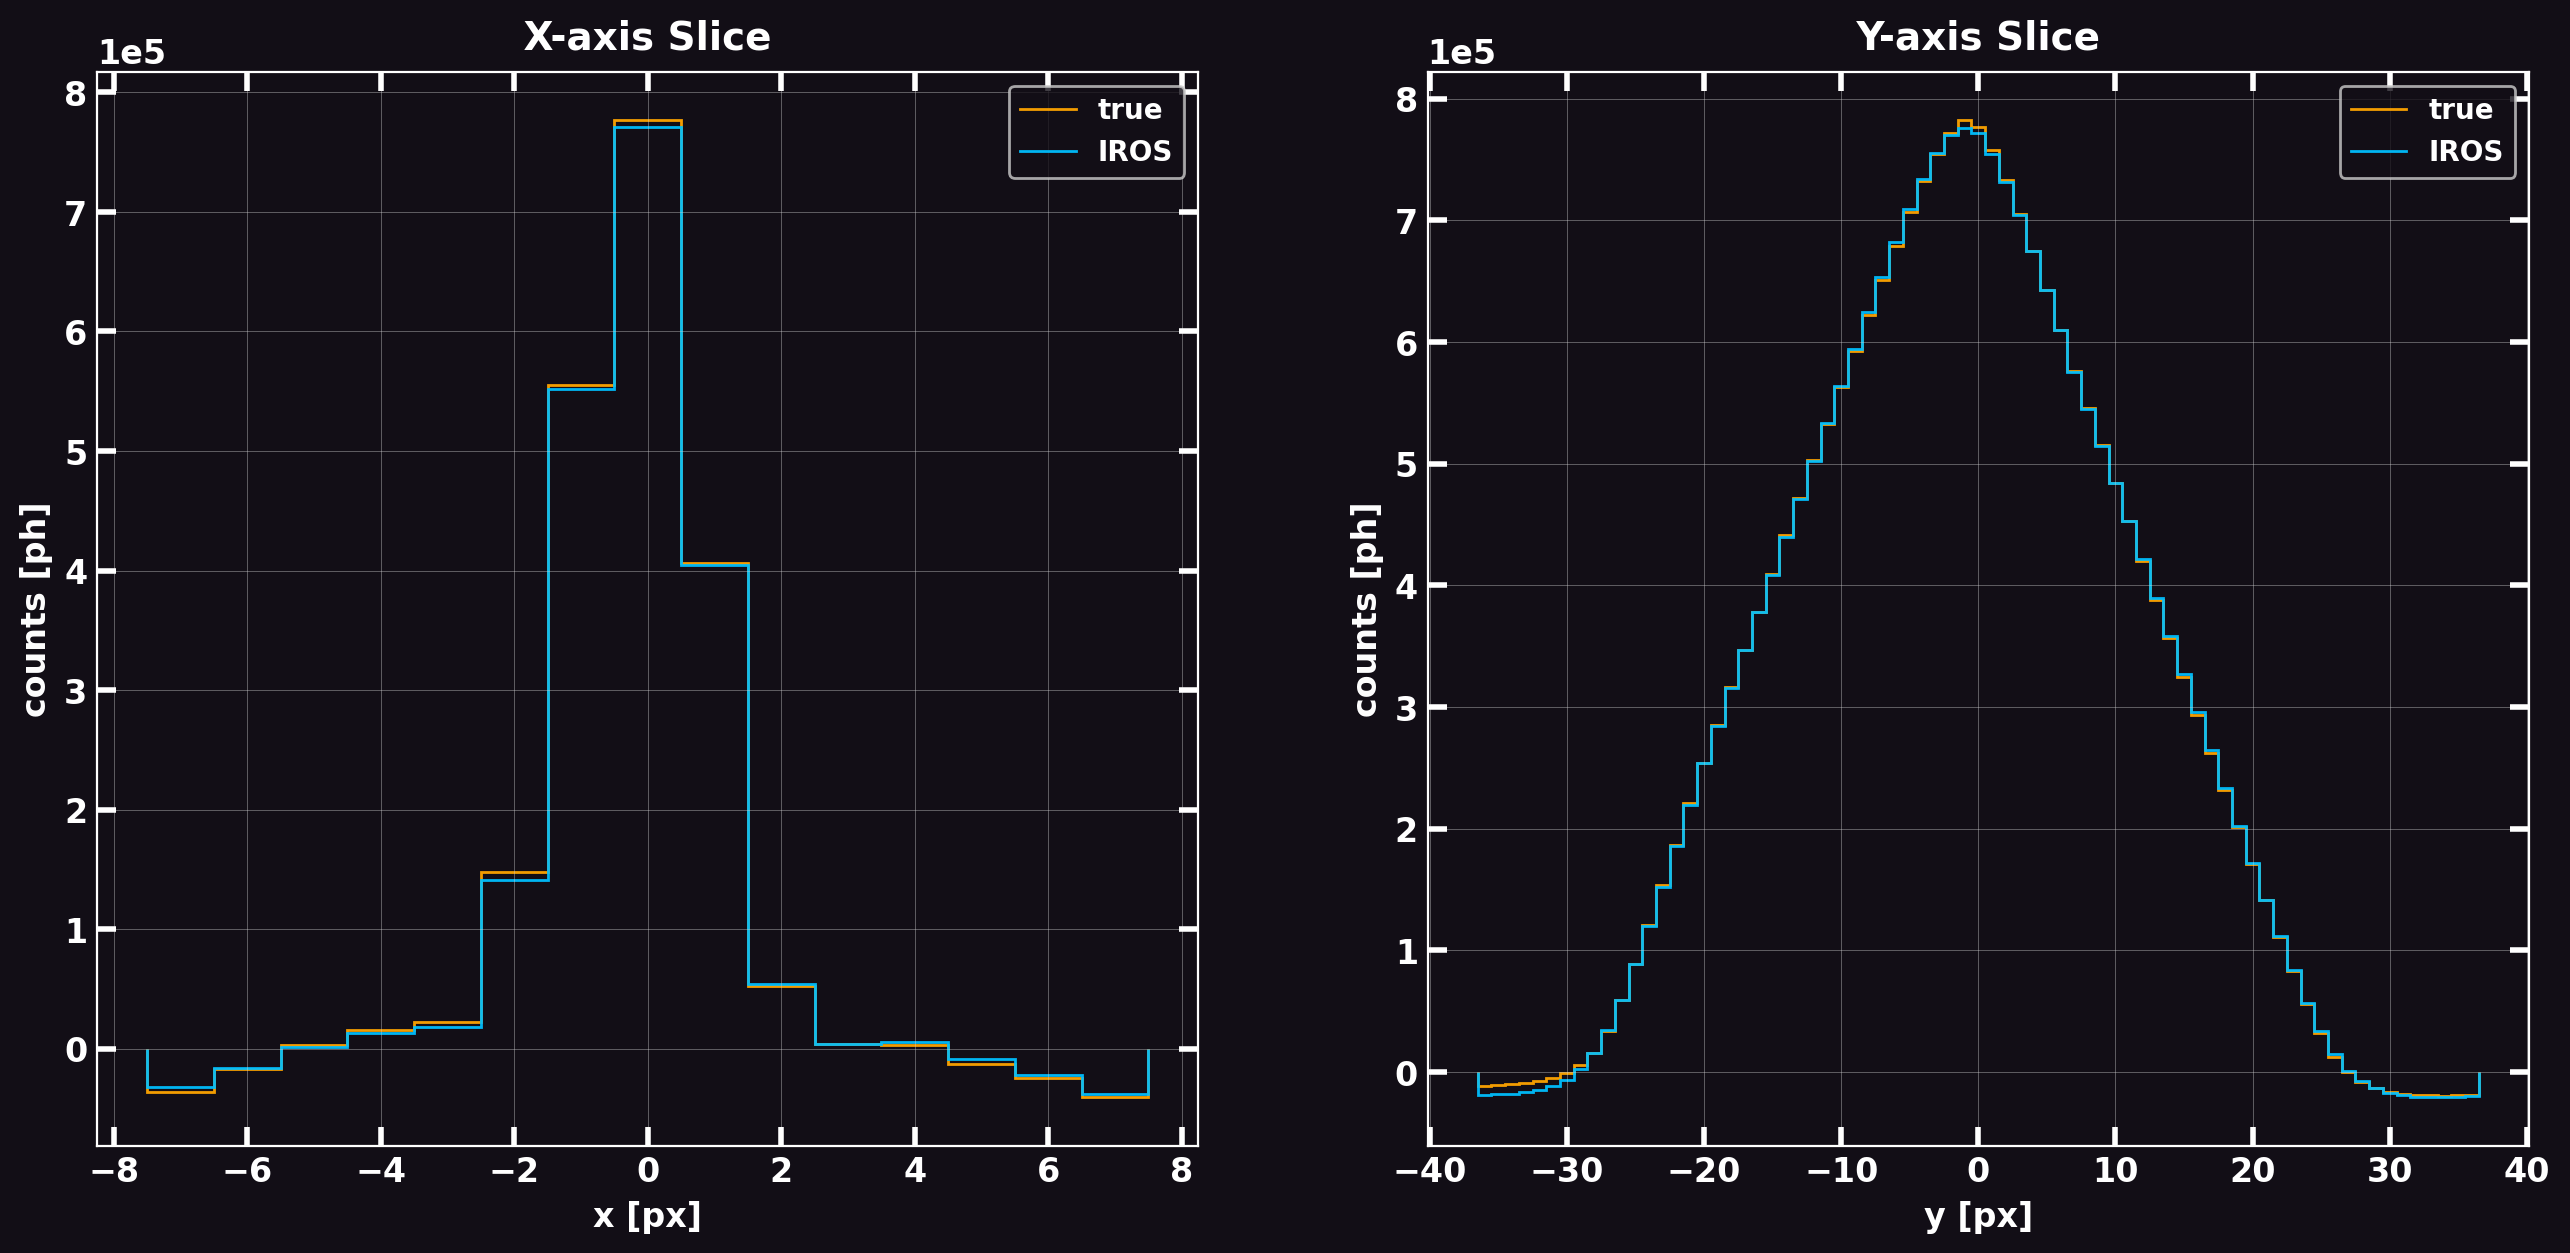

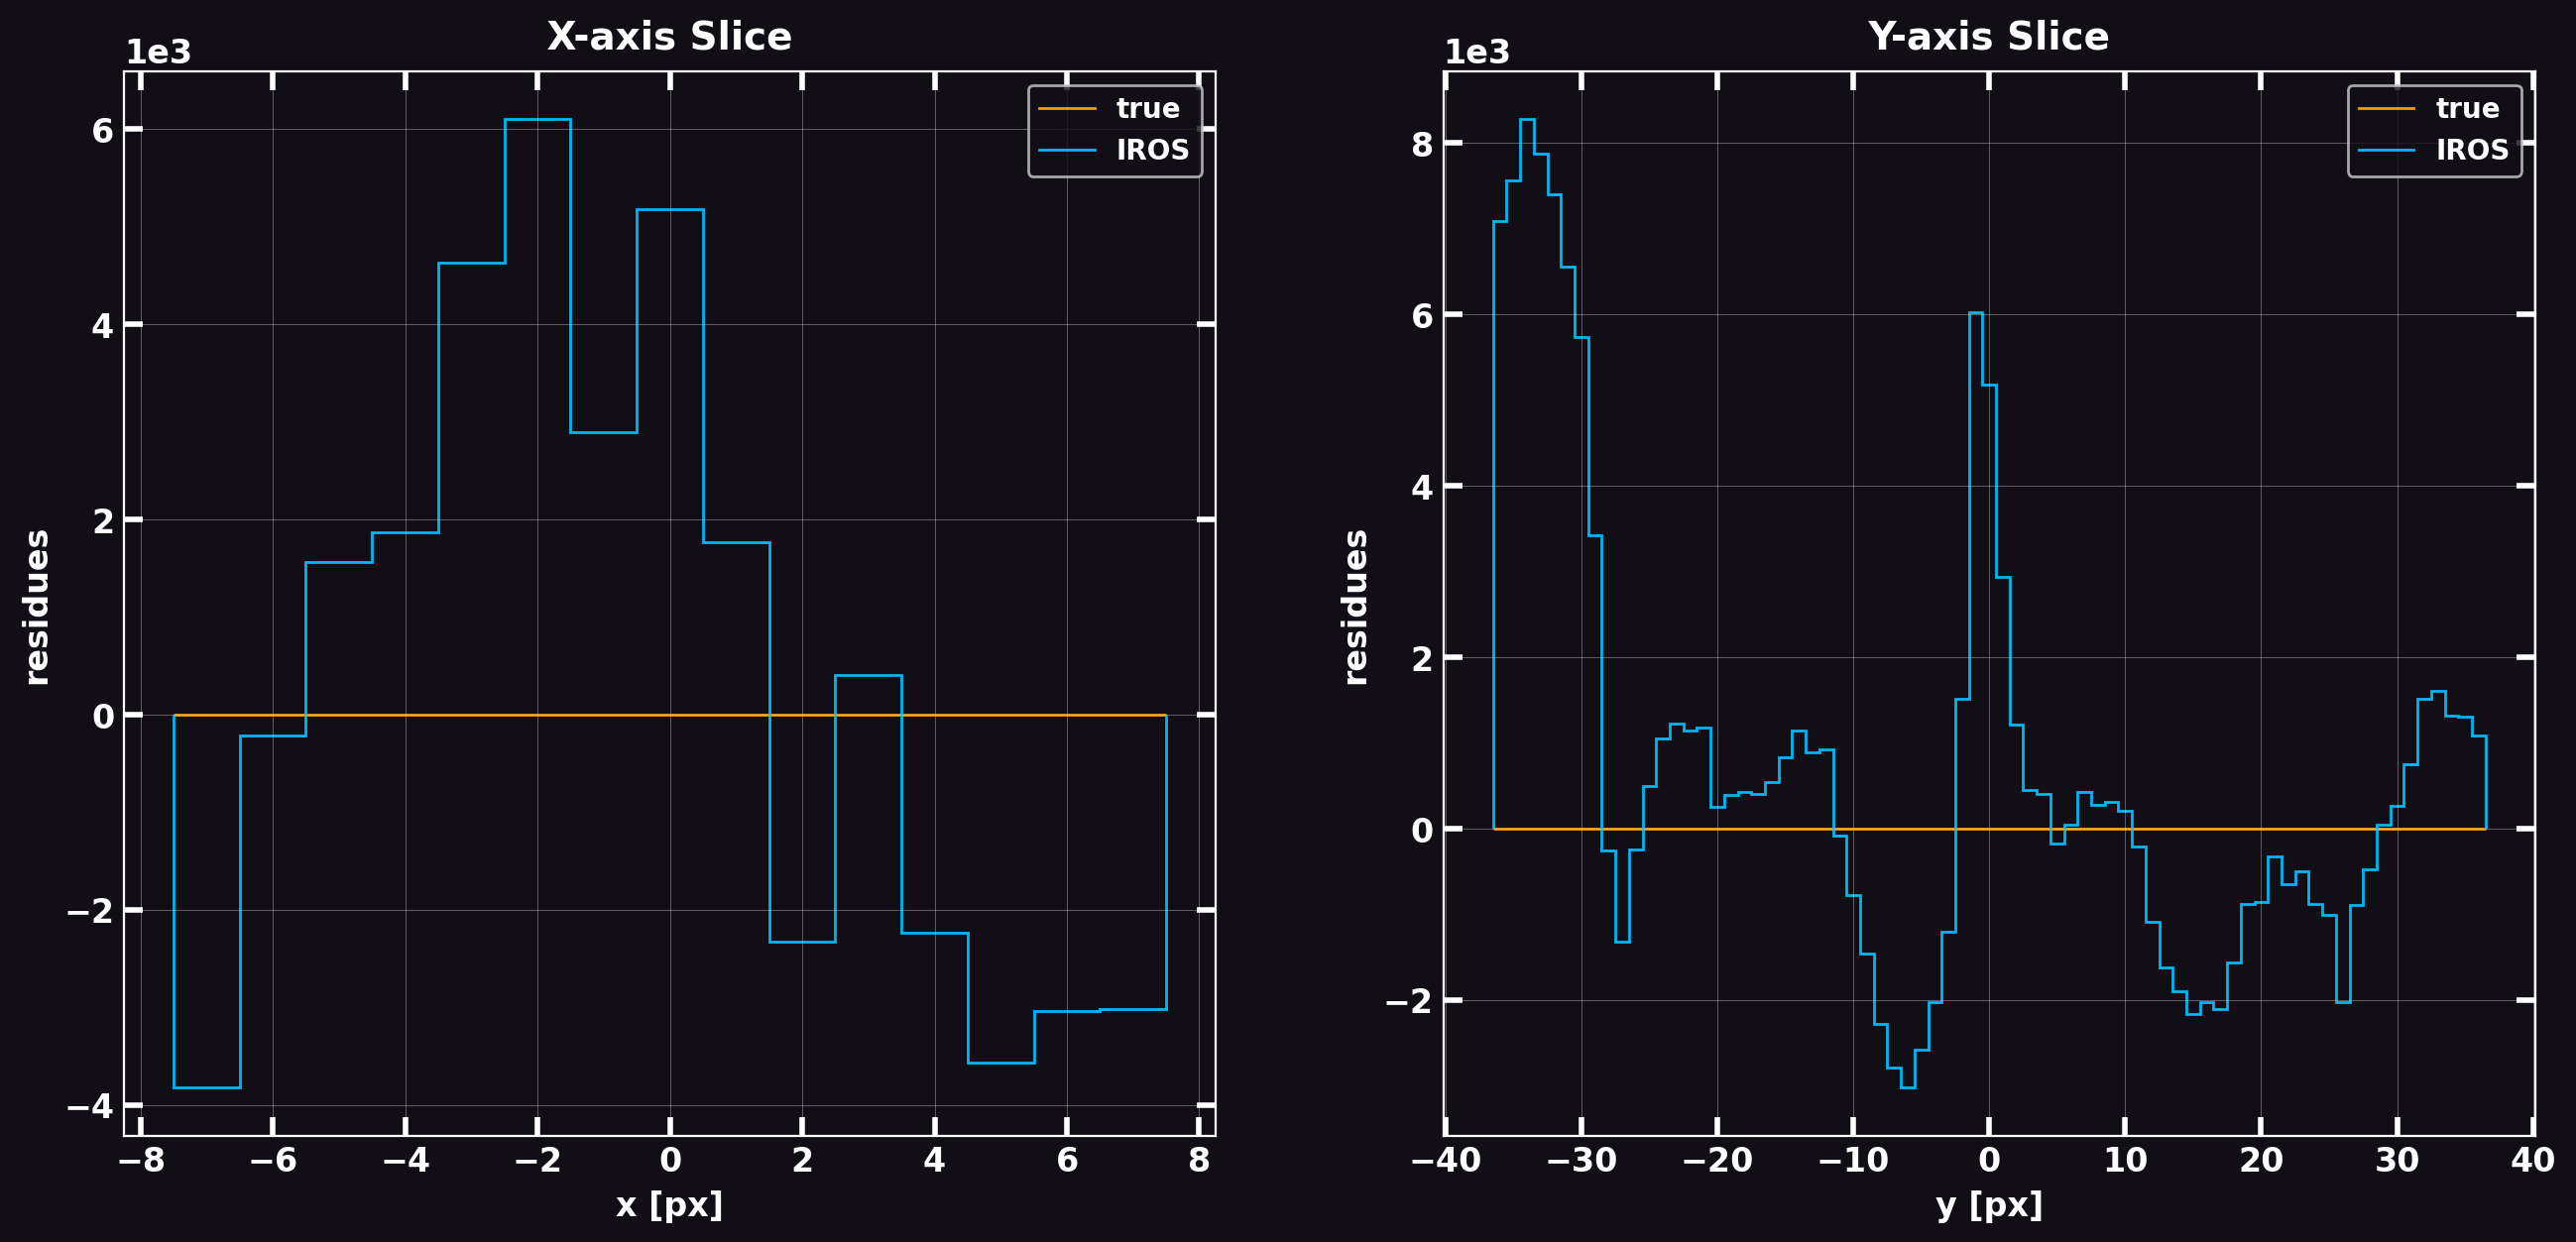

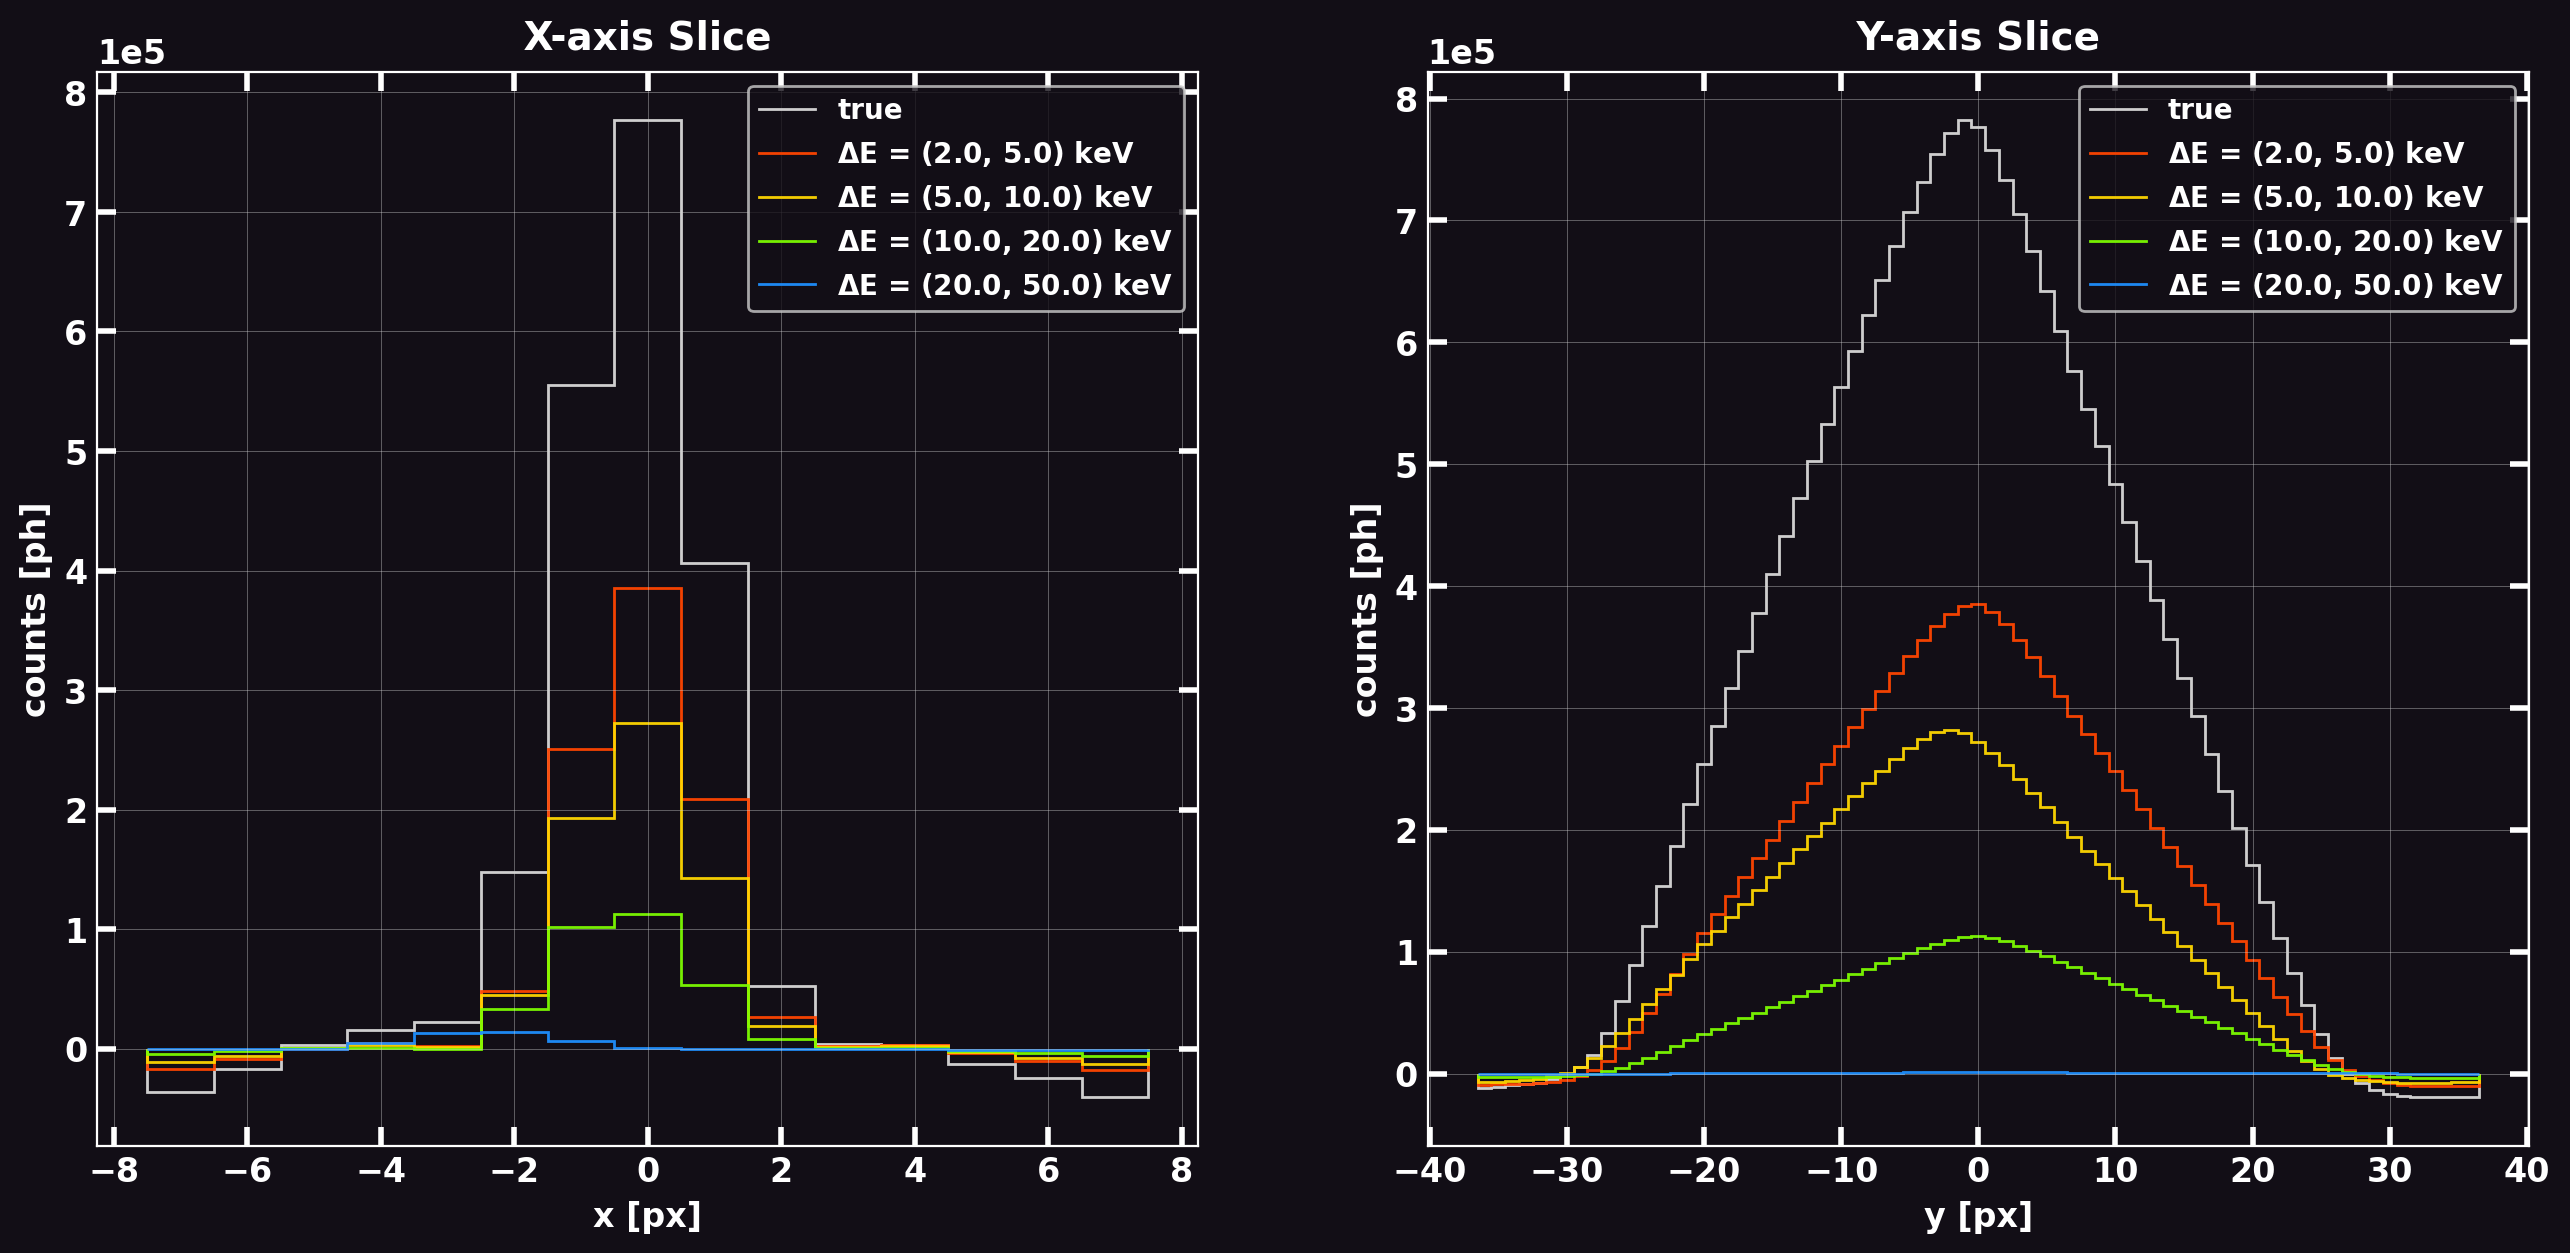

In [13]:
from bloodmoon.coords import shift2pos
from bloodmoon.images import argmax

def retrieve_skyimg_comps(camera: CodedMaskCamera, source: Candidate) -> tuple[NDArray, ...]:
    """Computes the components of the source in energy bands."""
    _flx_fracts = get_flx_fracts(tuple(source.coords.keys()))
    cts_vals: tuple[float, ...] = tuple(frc * source.cts for frc in _flx_fracts)
    # compute components shadowgrams
    sg_comps: tuple[NDArray, ...] = tuple(
        _project_mask_pattern(camera, *shifts) for shifts in tuple(source.coords.values())
    )
    if VIGNETTING:
        sx, sy = tuple(source.coords.values())[0]
        sg_comps = map(
            lambda sg: apply_vignetting(camera, sg, sx, sy),
            sg_comps,
        )
    if PSFY:
        sg_comps = map(
            lambda sg: apply_detector_resolution(camera, sg),
            sg_comps,
        )
    # extract detectors
    detectors: tuple[NDArray, ...] = map(
        lambda proj: _extract_detector(camera, proj),
        sg_comps,
    )
    # compute sky components
    sky_comps: tuple[NDArray, ...] = tuple(
        decode(camera, cts * det) for cts, det in zip(cts_vals, detectors)
    )
    return sky_comps


pos: tuple[int, int] = shift2pos(wfm, *cand.coords[energy_bands[0]])
#pos: tuple[int, int] = argmax(skymap)
_slit_fine, _slit_coarse = ds.psf_extension(wfm)
crp = (_slit_coarse + 5, _slit_fine + 5)

src_comps: tuple[NDArray, ...] = retrieve_skyimg_comps(wfm, cand)

ds.slices_plot(
    sky=(skymap, sum(src_comps)),
    pos=pos,
    crp=crp,
    ylabel='counts [ph]',
    labels=('true', 'IROS'),
    color=('Orange', 'DeepSkyBlue'),
)
ds.slices_plot(
    sky=(np.zeros_like(skyres), skyres),
    pos=pos,
    crp=crp,
    ylabel='residues',
    labels=['true', 'IROS'],
    color=('Orange', 'DeepSkyBlue'),
)
ds.slices_plot(
    sky=(skymap, *src_comps),
    pos=pos,
    crp=crp,
    ylabel='counts [ph]',
    labels=['true'] + [f'$\\Delta$E = {eband} keV' for eband in energy_bands],
    color=['#d9d9d9'] + _ebands_clrs,
)

In [15]:
assert False

AssertionError: 

In [ ]:
from typing import Iterable
import warnings

from bloodmoon.mask import decode
from bloodmoon.mask import variance
from bloodmoon.mask import snratio


def iros_singleCAM(
    detector: NDArray,
    camera: CodedMaskCamera,
    energy_bands: tuple[EnergyRange, ...],
    max_iterations: int = 5,
    snr_threshold: float = 5.0,
    vignetting: bool = True,
    psfy: bool = True,
    varmap: NDArray | None = None,
) -> Iterable[tuple[Candidate, NDArray]]:
    """
    Performs the Iterative Removal of Sources (IROS) algorithm for a single coded-mask
    camera of the Wide Field Monitor observations.
    """
    # operations setup
    optimiser = config_optimiser(
        camera, energy_bands, vignetting, psfy,
    )
    find_candidate, fit_candidate_params, subtract = config_IROS_operations(
        camera, optimiser, snr_threshold, vignetting, psfy,
    )
    # arrs setup
    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None
        else variance(camera, detector)
    )
    # looping as there's no tomorrow
    for i in range(max_iterations):
        snrmap = snratio(skymap, varmap)
        candidate_pos = find_candidate(skymap, snrmap)

        if not candidate_pos:
            print("\nNo candidates left...")
            break

        try:
            source = fit_candidate_params(candidate_pos, skymap, snrmap)
        except RuntimeError as e:
            warnings.warn(f"Optimizer failed at iteration {i}:\n\n{e}")
            continue

        detector_ = subtract(source, detector_)
        skymap = decode(camera, detector_)
        yield (source, skymap)

In [ ]:
def run_loop(loop: Iterable) -> tuple[Candidate, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    cands = tuple(source for source, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return cands

iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    energy_bands=energy_bands,
    max_iterations=max_iterations,
    snr_threshold=snr_threshold,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

cands: tuple[Candidate, ...] = run_loop(iros_loop)